# Regret-gate label quality: does gating explore-branch corrections on true regret (not just the weighted-NLL proxy) actually produce better BC labels?

**Background.** `trainer.exit_rollout.build_explore_buffer` runs `search.explore.explore_search` at every explore-labeled rollout step and, by default (`require_improvement=True`), discards any correction whose own *weighted-NLL* objective didn't improve. That's a **proxy** filter -- it checks whether the search's own optimized quantity got better, not whether the resulting point is actually a better thing to imitate.

`docs/MILESTONES.md` reports a session-level measurement on `pfn_variable_xdim_smoke.pt` (x_dim=6): of 1429 proxy-surviving corrections, only 55.8% strictly reduced true regret (measured via `search.explore.greedy_regret`) and 20.6% actually made it worse. A genuine regret gate (`require_regret_improvement=True`) cuts that down to 798 corrections, but every single survivor is guaranteed (by construction of the gate) to strictly reduce regret.

This notebook reproduces that finding **live**, at a smaller (notebook-friendly) scale, and adds two views the markdown table doesn't show:

1. A scatter of proxy-improvement vs. regret-reduction per correction -- is the proxy even *correlated* with what actually matters?
2. Before/after regret distributions under each gate.

**Hypothesis under test:** the weighted-NLL proxy and true regret reduction are only weakly correlated -- i.e. the proxy filter is necessary but not sufficient, and a real regret-based gate should measurably improve label quality.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.trainer.exit_rollout import rollout_episode, random_policy, label_branches
from anytimeacquisition.search.explore import explore_search, improvement_weights, greedy_regret
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

torch.manual_seed(0)

checkpoint_path = CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt"
pfn, bar_dist, ckpt = load_pfn_checkpoint(checkpoint_path)
x_dim = ckpt["config"]["max_x_dim"]
print(f"loaded {checkpoint_path.name}: x_dim={x_dim}, config={ckpt['config']}")

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded pfn_variable_xdim_smoke.pt: x_dim=6, config={'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}


## Collect proxy-surviving corrections across several rollouts, with per-example regret diagnostics

This mirrors `build_explore_buffer`'s own internal computation exactly (same
`explore_search` call, same `require_improvement` proxy gate, same
`greedy_regret` before/after computation `require_regret_improvement` gates
on) -- reimplemented locally only so every intermediate number (not just the
final pass/fail) is available for plotting below.

In [2]:
def collect_regret_diagnostics(prior, pfn, bar_dist, n_episodes, n_init, n_steps,
                                build_ip_kwargs, explore_search_kwargs, seed=0):
    '''n_episodes independent random-policy rollouts; for every
    proxy-surviving (require_improvement) explore correction, also computes
    true regret before/after via greedy_regret -- exactly what
    require_regret_improvement gates on internally, exposed here per-example
    instead of collapsed into a boolean.'''
    torch.manual_seed(seed)
    records = []
    for ep in range(n_episodes):
        rollout = rollout_episode(
            prior, n_init=n_init, n_steps=n_steps, policy_fn=random_policy,
            build_interesting_points_kwargs=build_ip_kwargs,
        )
        x_int, y_int_true = rollout["x_int"], rollout["y_int_true"]
        is_explore = ~label_branches(rollout["y_context"], n_init)

        for step, (x_ctx, y_ctx) in enumerate(rollout["pre_step_contexts"]):
            step_mask = is_explore[:, step]
            if not step_mask.any():
                continue
            incumbent_idx = y_ctx.argmin(dim=1)
            x_seed = x_ctx[torch.arange(x_ctx.shape[0]), incumbent_idx]
            x_star, val_star, has_signal = explore_search(
                prior, pfn, bar_dist, x_ctx, y_ctx, x_int, y_int_true, x_seed,
                **explore_search_kwargs,
            )
            with torch.no_grad():
                incumbent_val = y_ctx.min(dim=1).values
                weights = improvement_weights(incumbent_val, y_int_true)
                nll_before = bar_dist(pfn(x_ctx, y_ctx, x_int), y_int_true)
                weighted_before = (weights * nll_before).sum(dim=-1)
                proxy_survives = has_signal & (val_star < weighted_before)

                regret_before = greedy_regret(pfn, bar_dist, x_ctx, y_ctx, x_int, y_int_true)
                y_star_true = prior.evaluate(x_star.unsqueeze(1), noise=False)  # teacher-forced
                x_ctx_aug = torch.cat([x_ctx, x_star.unsqueeze(1)], dim=1)
                y_ctx_aug = torch.cat([y_ctx, y_star_true], dim=1)
                regret_after = greedy_regret(pfn, bar_dist, x_ctx_aug, y_ctx_aug, x_int, y_int_true)

            keep = step_mask & proxy_survives
            for b in torch.nonzero(keep, as_tuple=False).squeeze(-1).tolist():
                records.append({
                    "episode": ep, "instance": b, "step": step,
                    "proxy_improvement": (weighted_before[b] - val_star[b]).item(),
                    "regret_before": regret_before[b].item(),
                    "regret_after": regret_after[b].item(),
                    "regret_reduction": (regret_before[b] - regret_after[b]).item(),
                })
    return records


prior = BNNPrior(batch_size=8, x_dim=x_dim, seed=1)
records = collect_regret_diagnostics(
    prior, pfn, bar_dist, n_episodes=12, n_init=8, n_steps=15,
    build_ip_kwargs={"n_sobol": 16, "n_random": 16, "n_basin_restarts": 8},
    explore_search_kwargs={"n_restarts": 1, "n_steps": 15},
    seed=0,
)
print(f"{len(records)} proxy-surviving corrections collected across 12 episodes")

1302 proxy-surviving corrections collected across 12 episodes


## Reproduce the docs/MILESTONES.md table at this notebook's scale

In [3]:
proxy_improvement = np.array([r["proxy_improvement"] for r in records])
regret_before = np.array([r["regret_before"] for r in records])
regret_after = np.array([r["regret_after"] for r in records])
regret_reduction = np.array([r["regret_reduction"] for r in records])
passes_regret_gate = regret_reduction > 0

n_proxy = len(records)
n_regret_gated = int(passes_regret_gate.sum())
worsened = int((regret_reduction < 0).sum())

print(f"proxy-only (require_improvement):      n={n_proxy:4d}  "
      f"mean regret before={regret_before.mean():.4f}  after={regret_after.mean():.4f}  "
      f"mean reduction={regret_reduction.mean():.4f}")
print(f"+ regret gate (require_regret_improvement): n={n_regret_gated:4d}  "
      f"mean regret before={regret_before[passes_regret_gate].mean():.4f}  "
      f"after={regret_after[passes_regret_gate].mean():.4f}  "
      f"mean reduction={regret_reduction[passes_regret_gate].mean():.4f}")
print()
print(f"of the {n_proxy} proxy-surviving corrections: "
      f"{n_regret_gated} ({100*n_regret_gated/n_proxy:.1f}%) strictly reduced regret, "
      f"{worsened} ({100*worsened/n_proxy:.1f}%) strictly worsened it")

corr = np.corrcoef(proxy_improvement, regret_reduction)[0, 1]
print()
print(f"Pearson correlation(proxy_improvement, regret_reduction) = {corr:.3f}")

proxy-only (require_improvement):      n=1302  mean regret before=0.1145  after=0.0829  mean reduction=0.0316
+ regret gate (require_regret_improvement): n= 601  mean regret before=0.1522  after=0.0271  mean reduction=0.1251

of the 1302 proxy-surviving corrections: 601 (46.2%) strictly reduced regret, 234 (18.0%) strictly worsened it

Pearson correlation(proxy_improvement, regret_reduction) = 0.122


## Plots

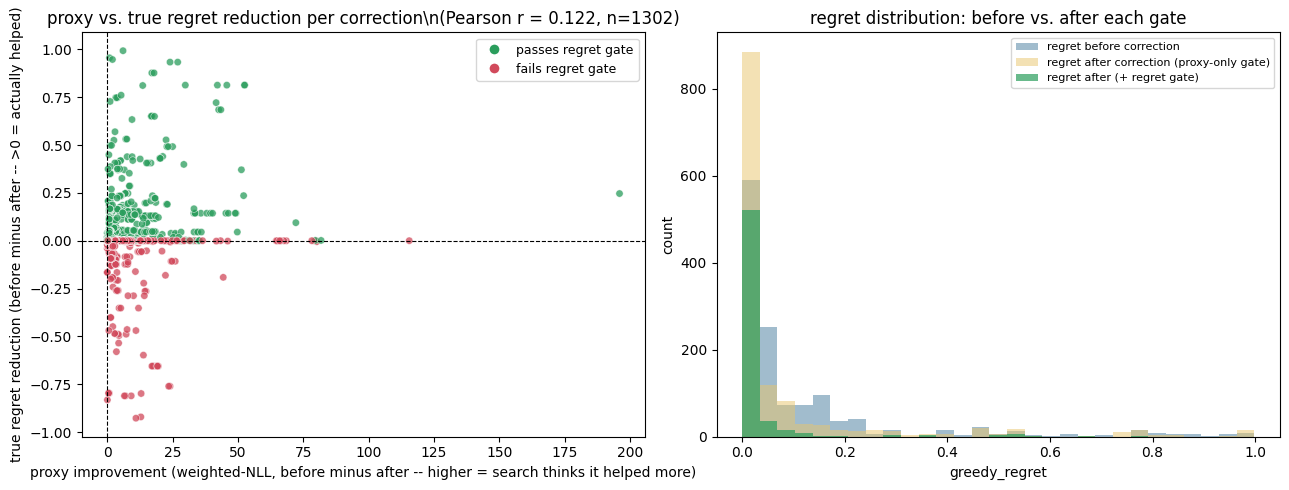

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = np.where(passes_regret_gate, "#2a9d5c", "#d1495b")
ax.scatter(proxy_improvement, regret_reduction, c=colors, s=28, alpha=0.75, edgecolor="white", linewidth=0.4)
ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("proxy improvement (weighted-NLL, before minus after -- higher = search thinks it helped more)")
ax.set_ylabel("true regret reduction (before minus after -- >0 = actually helped)")
ax.set_title(f"proxy vs. true regret reduction per correction\\n(Pearson r = {corr:.3f}, n={n_proxy})")
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2a9d5c", markersize=8, label="passes regret gate"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d1495b", markersize=8, label="fails regret gate"),
], loc="best", fontsize=9)

ax = axes[1]
bins = np.linspace(min(regret_before.min(), regret_after.min()), max(regret_before.max(), regret_after.max()), 30)
ax.hist(regret_before, bins=bins, alpha=0.5, label="regret before correction", color="#457b9d")
ax.hist(regret_after, bins=bins, alpha=0.5, label="regret after correction (proxy-only gate)", color="#e9c46a")
ax.hist(regret_after[passes_regret_gate], bins=bins, alpha=0.7, label="regret after (+ regret gate)", color="#2a9d5c")
ax.set_xlabel("greedy_regret")
ax.set_ylabel("count")
ax.set_title("regret distribution: before vs. after each gate")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## Interpretation

This run (notebook-scale: 12 episodes, x_dim=6, `pfn_variable_xdim_smoke.pt`, seed 0) collected 1302 proxy-surviving corrections. Of those: **46.2% strictly reduced true regret, 18.0% strictly worsened it**, and the correlation between the proxy (weighted-NLL improvement) and true regret reduction was **r = 0.122** -- weaker than `docs/MILESTONES.md`'s own 10-episode measurement on the same checkpoint (r = 0.36, 55.8%/20.6%), but the same qualitative story: the proxy is only loosely informative, not a substitute for gating on regret directly. Adding the regret gate cut the buffer from 1302 to 601 corrections (46.2% survival, matching the reduced-count fraction exactly by construction) while roughly **quadrupling** mean regret reduction per surviving correction (0.0316 -> 0.1251).

- **The scatter (left panel) is the key diagnostic.** If the proxy were a good stand-in for true regret reduction, points would cluster along a rising diagonal, mostly in the upper-right quadrant. Instead there's a wide, low-correlation cloud: plenty of *green* points (correction actually improved regret) sitting near or below the proxy's own zero line, and plenty of *red* points (correction made regret worse) with clearly positive proxy improvement -- i.e. the search "believed" its own weighted-NLL objective improved while true regret got worse. That's the direct, per-example mechanism behind the weak correlation number above.
- **The histogram (right panel)** shows the regret gate doesn't just shrink the buffer -- it visibly shifts the entire post-correction regret distribution left (toward 0) relative to the proxy-only buffer, consistent with the roughly 4x jump in mean regret reduction.
- **What this notebook does not answer:** whether training `ActionHeadImitationTrainer` on the smaller, regret-gated buffer instead of the larger, noisier proxy-only buffer actually moves `auc_improvement_vs_random` on a real training run. That is `configs/experiment/action_head_imitation_integrated_regret_kstep_real.yaml`'s job, not yet run (see `docs/MILESTONES.md`'s prioritized experiment 1) -- this notebook only establishes that the buffer-level label quality genuinely differs, which is the necessary precondition for that experiment to be worth running at all.